#### **Music Pattern Visualization using t-SNE**

##### **Problem Statement**

Music streaming platforms collect multiple audio features such as tempo, loudness, energy, danceability, and acousticness for each song.

However, these features are high-dimensional, making it difficult to visualize and understand similarities between songs or genres.

 This project aims to reduce high-dimensional audio features into a 2D space and visualize hidden patterns and clusters of songs using
t-Distributed Stochastic Neighbor Embedding.

##### **Project Objective** 

In this project, I aim to:

* Apply t-SNE to reduce high-dimensional audio features into 2D space
* Preserve similarity between songs (similar songs closer, different songs apart)
* Visualize hidden clusters of songs based on audio characteristics
* Identify patterns between different music genres
* Understand how songs group naturally without labels
* Explore relationships between audio features like energy, tempo, and loudness
* Improve interpretability of complex music data through visualization

In [ ]:
# Step : 1 Import required libraries 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [2]:
# Step 2 : Load the dataset 
df = pd.read_csv("music_tsne_dataset.csv")

# Display first 5 records 
print(df.head())

   Song_ID    Song_Name Genre   Tempo  Loudness  Energy  Danceability  \
0        1  Pop_Track_1   Pop  108.11     -3.25    0.84          0.81   
1        2  Pop_Track_2   Pop  100.46     -7.71    0.90          0.81   
2        3  Pop_Track_3   Pop   95.72     -3.15    0.88          0.67   
3        4  Pop_Track_4   Pop  101.42     -6.48    0.76          0.75   
4        5  Pop_Track_5   Pop  116.41     -7.30    0.67          0.73   

   Acousticness  
0          0.10  
1          0.26  
2          0.10  
3          0.14  
4          0.19  


In [3]:
# Step 3 Data Manipulation & Preprocessing 

print("\nDataset Shape : " , df.shape)            # Shape of dataset rows and columns
print("\nMissing Values : " , df.isnull().sum())  # Checking Missing values in dataset 
print("\nDuplicate Rows : " , df.duplicated().sum()) # Checking duplicate values 
# Show statistical summary
print("\nStatistical Summary : ")
print(df.describe())


Dataset Shape :  (200, 8)

Missing Values :  Song_ID         0
Song_Name       0
Genre           0
Tempo           0
Loudness        0
Energy          0
Danceability    0
Acousticness    0
dtype: int64

Duplicate Rows :  0

Statistical Summary : 
          Song_ID       Tempo    Loudness      Energy  Danceability  \
count  200.000000  200.000000  200.000000  200.000000    200.000000   
mean   100.500000  104.544650   -9.133950    0.592600      0.581000   
std     57.879185   22.611797    5.622022    0.234611      0.223645   
min      1.000000   60.610000  -24.830000    0.100000      0.100000   
25%     50.750000   85.047500  -12.230000    0.390000      0.390000   
50%    100.500000  104.920000   -7.190000    0.630000      0.610000   
75%    150.250000  118.122500   -4.782500    0.780000      0.770000   
max    200.000000  159.530000   -2.050000    0.990000      0.970000   

       Acousticness  
count    200.000000  
mean       0.387350  
std        0.302586  
min        0.020000  
25

In [4]:
# Step 4 : Select audio features 
# Song_ID , Song_Name , Genre are not used for modeling 
X = df.drop(["Song_ID" , "Song_Name" , "Genre"] , axis= 1 )


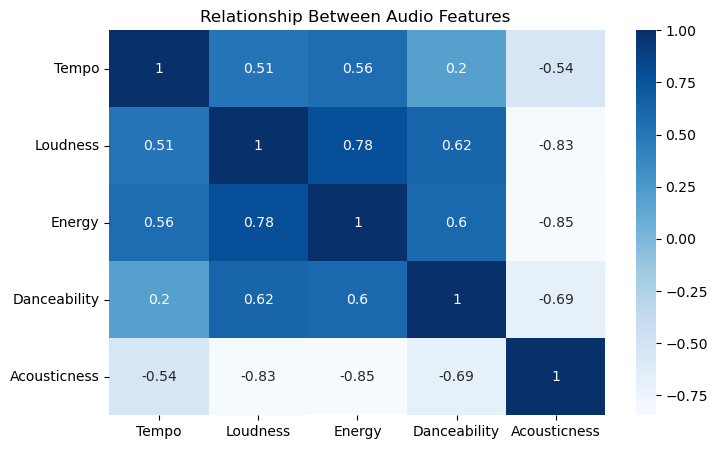

In [ ]:
# Step 5 : Check relationship between audio features
# Helps understand correlation between features 
plt.figure(figsize=(8 , 5))
sns.heatmap(
    X.corr(),
    annot= True,
    cmap="Blues"
)
plt.title("Relationship Between Audio Features ")
plt.savefig("images/Relationship between Audio Features.png")
plt.show()

In [7]:
# Step 6 : Scale audio features 
# Important for fair comparison between features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Step 7 : Apply t-SNE
# Convert high - dimensional data into 2D space 
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)
X_tsne = tsne.fit_transform(X_scaled)


In [ ]:
# Step 8 : Create t-SNE dataframe
tsne_df = pd.DataFrame(X_tsne , columns=["TSNE_1" , "TSNE_2"])

# Add reference columns 
tsne_df["Song_ID"] = df["Song_ID"]
tsne_df["Song_Name"] = df["Song_Name"]
tsne_df["Genre"] = df["Genre"]

# Display t-SNE output 
print("\nt-SNE Output : ")
print(tsne_df.head())


t-SNE Output : 
      TSNE_1    TSNE_2  Song_ID    Song_Name Genre
0  13.989404  5.403742        1  Pop_Track_1   Pop
1  14.902095  6.959918        2  Pop_Track_2   Pop
2  17.060318  6.191241        3  Pop_Track_3   Pop
3  15.391023  4.407064        4  Pop_Track_4   Pop
4  10.063442  5.687847        5  Pop_Track_5   Pop


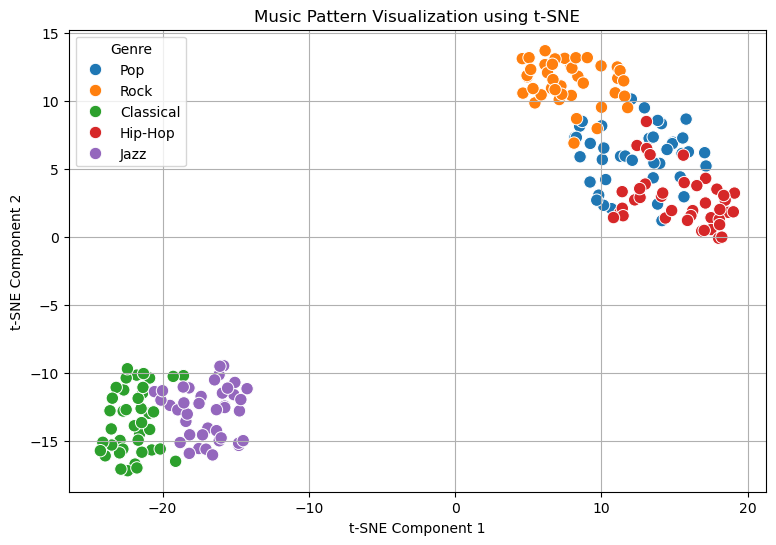

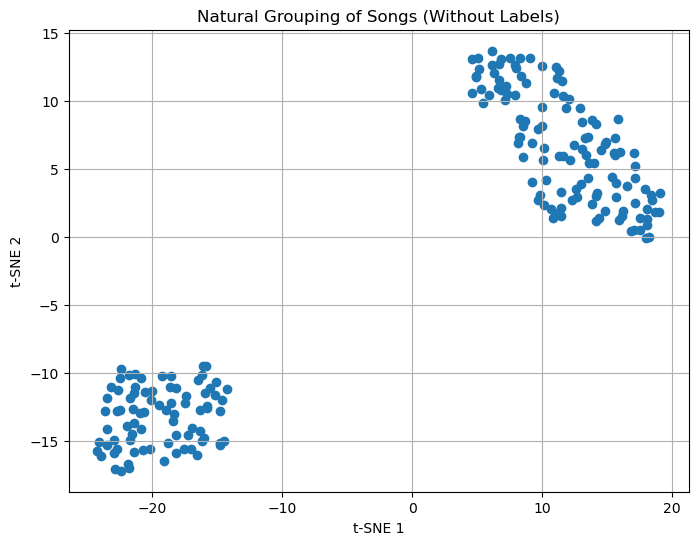

In [17]:
# Step 9 : Visualize hidden music patterns 
plt.figure(figsize=(9 , 6))

# Similar songs will appear closer 
sns.scatterplot(
    data = tsne_df,
    x = "TSNE_1",
    y = "TSNE_2",
    hue = "Genre",
    s = 80 
)

plt.title("Music Pattern Visualization using t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.savefig("images/Music Pattern Visualization.png")
plt.show()

# Step 9.1: Visualization without labels
plt.figure(figsize=(8,6))
plt.scatter(tsne_df["TSNE_1"], tsne_df["TSNE_2"])
plt.title("Natural Grouping of Songs (Without Labels)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(True)
plt.savefig("images/Natural Grouping of songs (witout labels ).png")
plt.show()

In [11]:
# Step 10 : Check genre distribution 
print("\nGenre Distribution: ")
print(df["Genre"].value_counts()) 


Genre Distribution: 
Genre
Pop          40
Rock         40
Classical    40
Hip-Hop      40
Jazz         40
Name: count, dtype: int64


In [12]:
# Step 11 : View sample output 
print("\nSample Song Pattern Output : ")
print(tsne_df[["Song_ID" , "Song_Name" , "Genre" , "TSNE_1" , "TSNE_2"]].head())


Sample Song Pattern Output : 
   Song_ID    Song_Name Genre     TSNE_1    TSNE_2
0        1  Pop_Track_1   Pop  13.989404  5.403742
1        2  Pop_Track_2   Pop  14.902095  6.959918
2        3  Pop_Track_3   Pop  17.060318  6.191241
3        4  Pop_Track_4   Pop  15.391023  4.407064
4        5  Pop_Track_5   Pop  10.063442  5.687847


In [13]:
# Step 12 : Final project insight 
print("\nFinal Observation:")
print("t-SNE reduced high-dimensional audio features into 2D space.")
print("Similar songs appear closer, preserving relationships.")
print("Different genres form visible clusters.")
print("Feature relationships were explored using correlation heatmap.")
print("This improves understanding of complex music patterns.")



Final Observation:
t-SNE reduced high-dimensional audio features into 2D space.
Similar songs appear closer, preserving relationships.
Different genres form visible clusters.
Feature relationships were explored using correlation heatmap.
This improves understanding of complex music patterns.


#### **Business Insights**

* Helps music platforms understand song similarity based on audio features
* Enables automatic grouping of similar songs for playlist generation
* Supports better music recommendation systems
* Reveals hidden patterns across different genres
* Simplifies complex audio data into clear visual insights
* Assists in data-driven decision-making for music analytics and personalization
- Can be extended for real-time music recommendation and clustering systems

#### **Conclusion**

In this project, I applied
t-Distributed Stochastic Neighbor Embedding
to visualize high-dimensional music data.

* Successfully reduced complex audio features into 2D space
* Similar songs were placed closer, preserving relationships
* Clear clustering patterns were observed across genres
* Natural grouping confirmed the effectiveness of unsupervised learning

 Overall, this project demonstrates how t-SNE helps in understanding complex data, discovering hidden patterns, and improving interpretability.